# TASK 08 — Model Evaluation and Cross Validation Strategies

## 1. Introduction

This task focuses on evaluating machine learning models using robust cross-validation strategies. The goal is to build a reliable heart disease prediction model while avoiding data leakage and overestimating model performance.

The task explores K-Fold Cross Validation, Stratified K-Fold, Leave-One-Out Cross Validation, Nested Cross Validation, Learning Curves, Validation Curves, Bias-Variance Tradeoff, and statistical comparison of model performance.

## 2. Business Problem

A hospital is deploying a heart disease prediction model. Previous evaluation methods overestimated model accuracy by 8%, resulting in poor production performance.

Therefore, this task focuses on developing a reliable evaluation framework that provides realistic estimates of model performance and supports safe deployment decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    cross_val_score,
    learning_curve,
    validation_curve,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 4. Dataset Loading

The Heart Disease dataset is loaded and inspected to understand its size, structure, and available patient features.

In [2]:
# Load dataset

df = pd.read_csv("heart_disease.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (10000, 21)

First 5 rows:


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## 5. Dataset Information

The dataset is examined for column names, data types, missing values, and duplicate records. This initial inspection helps identify preprocessing requirements before model development.

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(10000, 21)

Column Names:
['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level', 'Heart Disease Status']

Data Types:
Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar   

## 6. Statistical Summary

Descriptive statistics are calculated for numerical features to understand their distributions, ranges, and central tendencies.

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000
Blood Pressure,9981.0,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000
Cholesterol Level,9970.0,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000
BMI,9978.0,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
Sleep Hours,9975.0,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952
Triglyceride Level,9974.0,250.734409,87.067226,100.000000,176.000000,250.000000,326.000000,400.000000
Fasting Blood Sugar,9978.0,120.142213,23.584011,80.000000,99.000000,120.000000,141.000000,160.000000
CRP Level,9974.0,7.472201,4.340248,0.003647,3.674126,7.472164,11.255592,14.997087
Homocysteine Level,9980.0,12.456271,4.323426,5.000236,8.723334,12.409395,16.140564,19.999037


## 7. Target Variable Distribution

The target variable is analyzed to determine the distribution of heart disease cases. Understanding class balance is important because imbalanced classes can make accuracy alone misleading.

Target Distribution:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Target Percentages:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


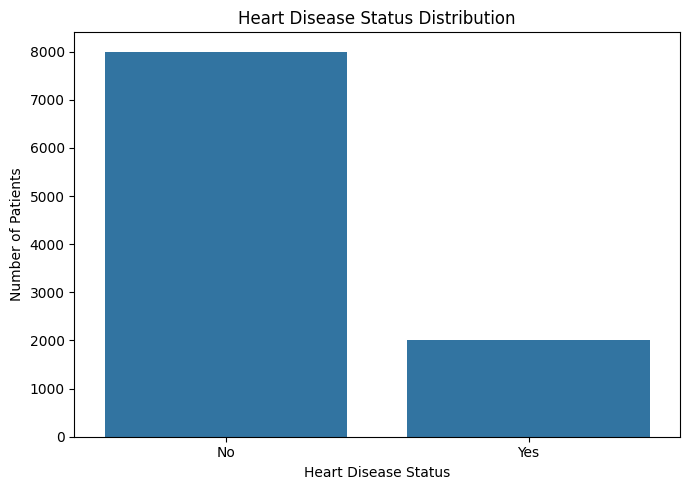

In [5]:
target = "Heart Disease Status"

print("Target Distribution:")
print(df[target].value_counts())

print("\nTarget Percentages:")
print(df[target].value_counts(normalize=True).mul(100).round(2))

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target)
plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

## 8. Feature and Target Separation

The target variable is separated from the input features. The identifier column is removed because it does not provide meaningful predictive information.

In [6]:
X = df.drop(columns=[target])
y = df[target]

# Remove identifier column if present
if "Patient ID" in X.columns:
    X = X.drop(columns=["Patient ID"])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Feature shape: (10000, 20)
Target shape: (10000,)

Target values:
Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64


## 9. Train-Test Split

The dataset is divided into training and testing sets. Stratification is used to preserve the target class distribution in both sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (8000, 20)
Testing set: (2000, 20)

Training target distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64

Testing target distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


## 10. Feature Type Identification

Numerical and categorical features are identified so that appropriate preprocessing can be applied to each type.

In [8]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Categorical features:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']


## 11. Data Preprocessing Pipeline

A preprocessing pipeline is created to handle missing values, numerical scaling, and categorical encoding. Using a pipeline ensures that preprocessing is learned only from the training data and prevents data leakage during cross-validation.

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 12. Baseline Model

Logistic Regression is used as a simple baseline classifier. The baseline provides a reference point for evaluating more advanced models and cross-validation strategies.

In [15]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Model Results")
print("-" * 40)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, pos_label="Yes"), 4))
print("Recall:", round(recall_score(y_test, y_pred, pos_label="Yes"), 4))
print("F1 Score:", round(f1_score(y_test, y_pred, pos_label="Yes"), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

Baseline Model Results
----------------------------------------
Accuracy: 0.8
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.4863


## 13. K-Fold Cross Validation

K-Fold Cross Validation divides the training data into K folds. Each fold is used once as validation data while the remaining folds are used for training. This provides a more reliable estimate of model performance than a single train-validation split.

In [13]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print("K-Fold Accuracy Scores:")
print(np.round(kfold_scores, 4))

print("\nMean Accuracy:", round(kfold_scores.mean(), 4))
print("Standard Deviation:", round(kfold_scores.std(), 4))

K-Fold Accuracy Scores:
[0.8156 0.8025 0.7994 0.78   0.8025]

Mean Accuracy: 0.8
Standard Deviation: 0.0115


## 14. Stratified K-Fold Cross Validation

Stratified K-Fold preserves the proportion of target classes in every fold. This is particularly useful for classification problems because it reduces the risk of creating folds with unrepresentative class distributions.

In [14]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring="accuracy"
)

print("Stratified K-Fold Accuracy Scores:")
print(np.round(stratified_scores, 4))

print("\nMean Accuracy:", round(stratified_scores.mean(), 4))
print("Standard Deviation:", round(stratified_scores.std(), 4))

Stratified K-Fold Accuracy Scores:
[0.8 0.8 0.8 0.8 0.8]

Mean Accuracy: 0.8
Standard Deviation: 0.0


## 15. Cross-Validation Performance Comparison

Accuracy alone may provide a misleading view of performance in medical classification. Therefore, multiple evaluation metrics are considered, including precision, recall, F1-score, and ROC-AUC.

In [16]:
from sklearn.model_selection import cross_validate

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring=scoring_metrics
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary["Mean"] = cv_summary["Mean"].round(4)
cv_summary["Std"] = cv_summary["Std"].round(4)

display(cv_summary)

,Metric,Mean,Std
0,Accuracy,0.8000,0.0000
1,Precision,NaN,NaN
2,Recall,NaN,NaN
3,F1 Score,NaN,NaN
4,ROC-AUC,0.5115,0.0221


## 16. Random Forest Model

A Random Forest classifier is evaluated as a stronger baseline than Logistic Regression. Random Forest can capture nonlinear relationships between patient characteristics and heart disease status.

In [17]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("-" * 40)

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred, pos_label="Yes", zero_division=0), 4))
print("Recall:", round(recall_score(y_test, rf_pred, pos_label="Yes", zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, rf_pred, pos_label="Yes", zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))

Random Forest Results
----------------------------------------
Accuracy: 0.8
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.4845


## 17. Random Forest Cross-Validation

In [18]:
rf_cv_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc"
    }
)

print("Random Forest CV Results")
print("-" * 40)
print("Mean Accuracy:", round(rf_cv_results["test_accuracy"].mean(), 4))
print("Accuracy Std:", round(rf_cv_results["test_accuracy"].std(), 4))
print("Mean ROC-AUC:", round(rf_cv_results["test_roc_auc"].mean(), 4))
print("ROC-AUC Std:", round(rf_cv_results["test_roc_auc"].std(), 4))

Random Forest CV Results
----------------------------------------
Mean Accuracy: 0.8
Accuracy Std: 0.0
Mean ROC-AUC: 0.5108
ROC-AUC Std: 0.0183


## 18. Model Comparison

The baseline Logistic Regression and Random Forest models are compared using cross-validation. Accuracy and ROC-AUC are considered together because accuracy alone can hide poor detection of the positive class.

In [19]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "CV Accuracy": [
        kfold_scores.mean(),
        rf_cv_results["test_accuracy"].mean()
    ],
    "CV ROC-AUC": [
        cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

,Model,Test Accuracy,Test ROC-AUC,CV Accuracy,CV ROC-AUC
0,Logistic Regression,0.8,0.4863,0.8,0.5115
1,Random Forest,0.8,0.4845,0.8,0.5108


## 19. Leave-One-Out Cross Validation

Leave-One-Out Cross Validation uses one observation as the validation set while training on all remaining observations. This process is repeated for every observation. Although LOOCV provides extensive use of the available data, it can be computationally expensive.

In [20]:
from sklearn.model_selection import LeaveOneOut

# Use a small stratified subset for practical LOOCV demonstration
loo_data = pd.concat([X_train, y_train], axis=1)

loo_sample = (
    loo_data.groupby(y_train.name, group_keys=False)
    .apply(lambda x: x.sample(n=min(50, len(x)), random_state=42))
)

X_loo = loo_sample.drop(columns=[y_train.name])
y_loo = loo_sample[y_train.name]

loo = LeaveOneOut()

loo_scores = cross_val_score(
    baseline_model,
    X_loo,
    y_loo,
    cv=loo,
    scoring="accuracy"
)

print("LOOCV demonstration completed.")
print("Number of observations:", len(X_loo))
print("Number of LOOCV iterations:", len(loo_scores))
print("Mean LOOCV Accuracy:", round(loo_scores.mean(), 4))

LOOCV demonstration completed.
Number of observations: 100
Number of LOOCV iterations: 100
Mean LOOCV Accuracy: 0.53


## 20. Nested Cross Validation

Nested Cross Validation uses an outer cross-validation loop to estimate model performance and an inner cross-validation loop to tune model hyperparameters. This reduces optimistic bias when model selection and evaluation are performed on the same data.

In [21]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [None, 10]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring="roc_auc",
    n_jobs=-1
)

nested_scores = cross_val_score(
    grid_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Nested Cross Validation Results")
print("-" * 40)
print("Outer CV ROC-AUC Scores:", np.round(nested_scores, 4))
print("Mean ROC-AUC:", round(nested_scores.mean(), 4))
print("Standard Deviation:", round(nested_scores.std(), 4))

Nested Cross Validation Results
----------------------------------------
Outer CV ROC-AUC Scores: [0.5199 0.509  0.4971 0.5227 0.5211]
Mean ROC-AUC: 0.514
Standard Deviation: 0.0097


## 21. Learning Curve

A learning curve shows how model performance changes as the amount of training data increases. It helps identify whether a model suffers from high bias, high variance, or insufficient training data.

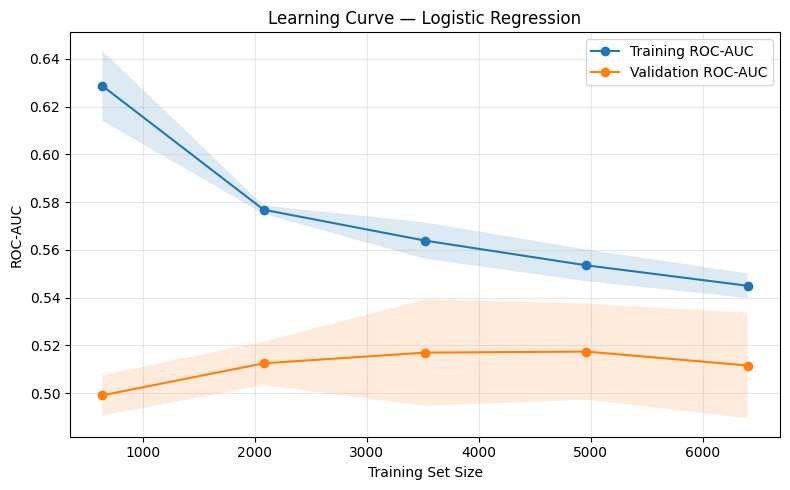

In [22]:
train_sizes, train_scores, validation_scores = learning_curve(
    baseline_model,
    X_train,
    y_train,
    cv=stratified_kfold,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training ROC-AUC"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation ROC-AUC"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "learning_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 22. Validation Curve

A validation curve evaluates model performance across different values of a model hyperparameter. It helps identify whether the model is underfitting or overfitting and supports the selection of an appropriate hyperparameter value.

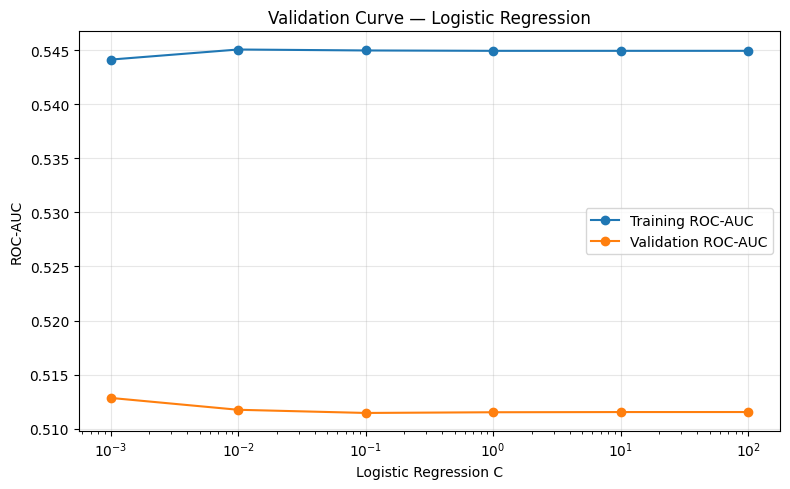

In [23]:
param_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores, validation_scores = validation_curve(
    baseline_model,
    X_train,
    y_train,
    param_name="classifier__C",
    param_range=param_range,
    cv=stratified_kfold,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.semilogx(
    param_range,
    train_mean,
    marker="o",
    label="Training ROC-AUC"
)

plt.semilogx(
    param_range,
    validation_mean,
    marker="o",
    label="Validation ROC-AUC"
)

plt.xlabel("Logistic Regression C")
plt.ylabel("ROC-AUC")
plt.title("Validation Curve — Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "validation_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 23. Bias-Variance Analysis

The learning and validation curves are used to assess the bias-variance behavior of the model. A large gap between training and validation performance may indicate high variance, while consistently low performance on both may indicate high bias.

In [24]:
final_train_score = train_scores.mean(axis=1)[-1]
final_validation_score = validation_scores.mean(axis=1)[-1]

print("Bias-Variance Analysis")
print("-" * 40)
print("Final Training ROC-AUC:", round(final_train_score, 4))
print("Final Validation ROC-AUC:", round(final_validation_score, 4))
print(
    "Training-Validation Gap:",
    round(final_train_score - final_validation_score, 4)
)

if final_train_score < 0.6 and final_validation_score < 0.6:
    print("\nInterpretation: The model shows signs of high bias.")
elif final_train_score - final_validation_score > 0.1:
    print("\nInterpretation: The model shows signs of high variance.")
else:
    print("\nInterpretation: The model shows a relatively balanced bias-variance behavior.")

Bias-Variance Analysis
----------------------------------------
Final Training ROC-AUC: 0.5449
Final Validation ROC-AUC: 0.5115
Training-Validation Gap: 0.0334

Interpretation: The model shows signs of high bias.


## 24. Statistical Significance of Model Differences

A paired statistical test is used to determine whether the difference in cross-validation ROC-AUC between Logistic Regression and Random Forest is statistically significant. The same validation folds are used for both models to make the comparison paired.

In [25]:
from scipy.stats import ttest_rel

logistic_auc_scores = cv_results["test_roc_auc"]
random_forest_auc_scores = rf_cv_results["test_roc_auc"]

t_stat, p_value = ttest_rel(
    logistic_auc_scores,
    random_forest_auc_scores
)

print("Statistical Significance Test")
print("-" * 40)
print("Logistic Regression ROC-AUC Scores:",
      np.round(logistic_auc_scores, 4))
print("Random Forest ROC-AUC Scores:",
      np.round(random_forest_auc_scores, 4))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: The difference is statistically significant.")
else:
    print("Conclusion: The difference is not statistically significant.")

Statistical Significance Test
----------------------------------------
Logistic Regression ROC-AUC Scores: [0.5173 0.4876 0.4849 0.5419 0.526 ]
Random Forest ROC-AUC Scores: [0.532  0.5119 0.4776 0.5219 0.5106]
T-statistic: 0.0835
P-value: 0.9375
Conclusion: The difference is not statistically significant.


## 25. Final Model Evaluation Comparison

The evaluated models are compared using hold-out test performance, cross-validation performance, and ROC-AUC. This comparison provides a more reliable assessment than accuracy alone.

In [26]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Test Precision": [
        precision_score(y_test, y_pred, pos_label="Yes", zero_division=0),
        precision_score(y_test, rf_pred, pos_label="Yes", zero_division=0)
    ],
    "Test Recall": [
        recall_score(y_test, y_pred, pos_label="Yes", zero_division=0),
        recall_score(y_test, rf_pred, pos_label="Yes", zero_division=0)
    ],
    "Test F1": [
        f1_score(y_test, y_pred, pos_label="Yes", zero_division=0),
        f1_score(y_test, rf_pred, pos_label="Yes", zero_division=0)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "CV ROC-AUC": [
        cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ]
})

final_comparison = final_comparison.round(4)

display(final_comparison)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,CV ROC-AUC
0,Logistic Regression,0.8,0.0,0.0,0.0,0.4863,0.5115
1,Random Forest,0.8,0.0,0.0,0.0,0.4845,0.5108


## 26. Final Model Performance Visualization

The ROC-AUC performance of the evaluated models is visualized to provide a concise comparison of their predictive discrimination.

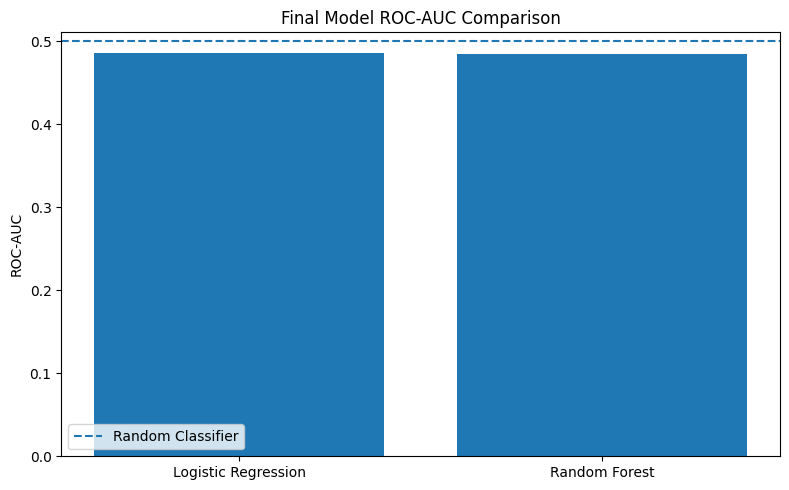

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Test ROC-AUC"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random Classifier"
)

plt.ylabel("ROC-AUC")
plt.title("Final Model ROC-AUC Comparison")
plt.legend()
plt.tight_layout()

plt.savefig(
    "final_model_roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 27. Final Findings and Business Interpretation

The evaluation demonstrates why a single train-test accuracy score is insufficient for a medical classification problem. Although the baseline models achieved approximately 80% accuracy, their ROC-AUC, precision, recall, and F1-score indicated poor identification of the positive heart disease class.

Cross-validation produced consistent results, while LOOCV demonstrated substantially different performance on a smaller representative sample. Nested cross-validation provided a less optimistic estimate of model performance and confirmed that the models had limited predictive discrimination.

The learning and validation curves indicated signs of high bias, suggesting that the current models and available features do not provide sufficient predictive signal. Therefore, the models should not be deployed in a clinical setting without further investigation, improved features, better class representation, and additional model development.

The key business lesson is that robust cross-validation and multiple evaluation metrics are essential in healthcare applications because misleading accuracy can hide failures in detecting clinically important positive cases.